# Analisis ORB dan AKAZE pada Citra Augmentasi

Notebook ini digunakan untuk demonstrasi dan analisis feature extraction pada final project Computer Vision. Fokus utama notebook adalah membandingkan performa dua metode deteksi fitur lokal, yaitu ORB dan AKAZE, pada citra original dan citra hasil augmentasi seperti Gaussian blur, Gaussian noise, dan JPEG compression.

Feature extraction merupakan proses mendeteksi titik-titik penting (keypoints) pada citra serta menghasilkan representasi numerik yang disebut descriptor. Descriptor digunakan untuk merepresentasikan pola lokal di sekitar keypoint sehingga dapat dianalisis lebih lanjut pada proses Computer Vision.

Pada notebook ini, ORB dan AKAZE digunakan untuk mendeteksi keypoints dan descriptor dari berbagai kondisi citra. Hasil analisis meliputi:
- jumlah keypoints yang berhasil dideteksi
- bentuk descriptor
- rata-rata nilai descriptor
- variance descriptor
- visualisasi keypoints pada citra

Analisis ini bertujuan untuk memahami bagaimana augmentasi citra mempengaruhi stabilitas dan kualitas fitur lokal yang dihasilkan oleh masing-masing metode.

In [12]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 2. Import Library dan Definisi Path

Bagian ini memuat library utama yang digunakan pada proses feature extraction dan visualisasi. OpenCV digunakan untuk melakukan deteksi keypoints dan descriptor menggunakan ORB dan AKAZE, sedangkan Matplotlib digunakan untuk menampilkan hasil visualisasi keypoints.

Notebook akan membaca dataset dari folder `dataset/` yang berisi citra original dan citra hasil augmentasi. Selain itu, notebook juga akan menyimpan visualisasi dan hasil analisis statistik ke folder `outputs/`.

In [13]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASET_DIR = PROJECT_ROOT / "dataset"

AUGMENTATIONS = {
    "original": DATASET_DIR / "original" / "train" / "real",
    "gaussian_blur": DATASET_DIR / "gaussian_blur" / "train" / "real",
    "gaussian_noise": DATASET_DIR / "gaussian_noise" / "train" / "real",
    "jpeg_compression": DATASET_DIR / "jpeg_compression" / "train" / "real",
}

# 3. Load Original dan Augmented Images

Tahap ini bertujuan untuk membaca citra original dan citra hasil augmentasi dari dataset. Setiap citra akan dimuat dalam format RGB untuk visualisasi dan grayscale untuk proses feature extraction.

Konversi grayscale dilakukan karena sebagian besar algoritma feature detection bekerja pada intensitas cahaya dibandingkan informasi warna. Hal ini membantu proses deteksi keypoints menjadi lebih stabil dan efisien secara komputasi.

Grid visualisasi digunakan untuk memastikan bahwa citra berhasil dimuat dengan benar sebelum masuk ke proses deteksi fitur.

In [14]:
def get_first_image(folder):

    for extension in ("*.jpg", "*.jpeg", "*.JPG", "*.JPEG"):

        images = list(folder.glob(extension))

        if images:
            return images[0]

    raise FileNotFoundError(f"No image found in {folder}")


def load_image(image_path):

    image_bgr = cv2.imread(str(image_path))

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    return image_bgr, image_rgb, image_gray

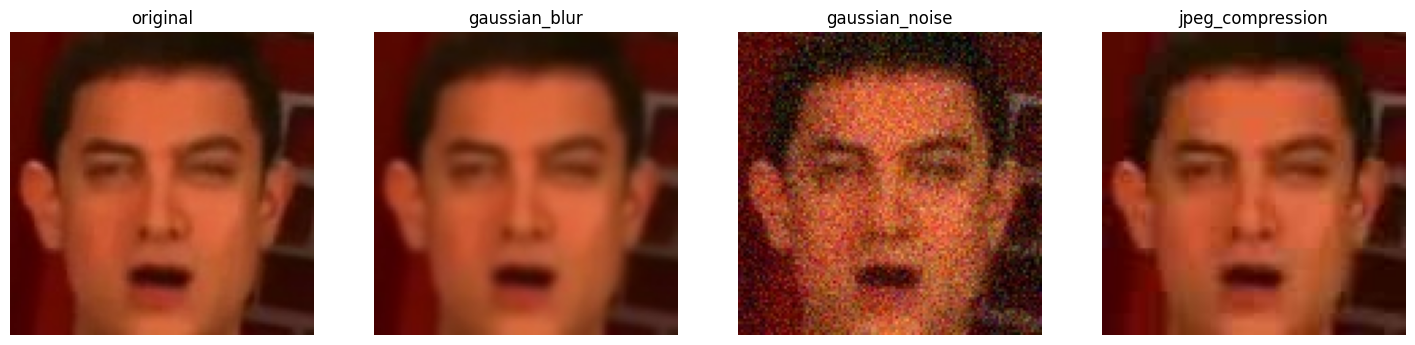

In [15]:
images = {}

for augmentation, folder in AUGMENTATIONS.items():

    image_path = get_first_image(folder)

    image_bgr, image_rgb, image_gray = load_image(image_path)

    images[augmentation] = {
        "path": image_path,
        "bgr": image_bgr,
        "rgb": image_rgb,
        "gray": image_gray,
    }

fig, axes = plt.subplots(1, 4, figsize=(18,5))

for ax, (augmentation, data) in zip(axes, images.items()):

    ax.imshow(data["rgb"])
    ax.set_title(augmentation)
    ax.axis("off")

plt.show()

# 4. ORB Feature Extraction

ORB (Oriented FAST and Rotated BRIEF) merupakan metode feature extraction yang dirancang agar cepat dan ringan secara komputasi. ORB menggabungkan algoritma FAST untuk mendeteksi keypoints dan BRIEF untuk menghasilkan descriptor biner.

Keunggulan ORB:
- proses komputasi cepat
- cocok untuk aplikasi real-time
- efisien pada perangkat dengan resource terbatas
- tahan terhadap rotasi citra

Pada tahap ini, ORB digunakan untuk mendeteksi keypoints dan menghasilkan descriptor dari citra grayscale. Jumlah keypoints dan statistik descriptor digunakan sebagai indikator kualitas fitur yang berhasil dideteksi.

In [16]:
orb = cv2.ORB_create(nfeatures=1000)

orb_results = {}

for augmentation, data in images.items():

    keypoints, descriptors = orb.detectAndCompute(
        data["gray"],
        None
    )

    orb_results[augmentation] = {
        "keypoints": keypoints,
        "descriptors": descriptors,
    }

    print(f"\nAugmentation: {augmentation}")
    print("Number of keypoints:", len(keypoints))
    print("Descriptor shape:", descriptors.shape)
    print("Descriptor mean:", np.mean(descriptors))
    print("Descriptor variance:", np.var(descriptors))


Augmentation: original
Number of keypoints: 11
Descriptor shape: (11, 32)
Descriptor mean: 137.51136363636363
Descriptor variance: 5101.8919163223145

Augmentation: gaussian_blur
Number of keypoints: 3
Descriptor shape: (3, 32)
Descriptor mean: 139.45833333333334
Descriptor variance: 5744.477430555555

Augmentation: gaussian_noise
Number of keypoints: 176
Descriptor shape: (176, 32)
Descriptor mean: 132.62180397727272
Descriptor variance: 5645.4951069729395

Augmentation: jpeg_compression
Number of keypoints: 11
Descriptor shape: (11, 32)
Descriptor mean: 139.01988636363637
Descriptor variance: 5594.8376727143595


# 5. Visualisasi Keypoints ORB

Visualisasi keypoints dilakukan menggunakan `cv2.drawKeypoints()` untuk menampilkan lokasi titik-titik penting yang berhasil dideteksi oleh ORB.

Titik-titik ini merepresentasikan area citra yang memiliki informasi lokal kuat, seperti sudut, tepi, atau tekstur tertentu. Semakin banyak keypoints yang stabil terdeteksi, semakin banyak informasi lokal yang dapat digunakan pada proses analisis Computer Vision.

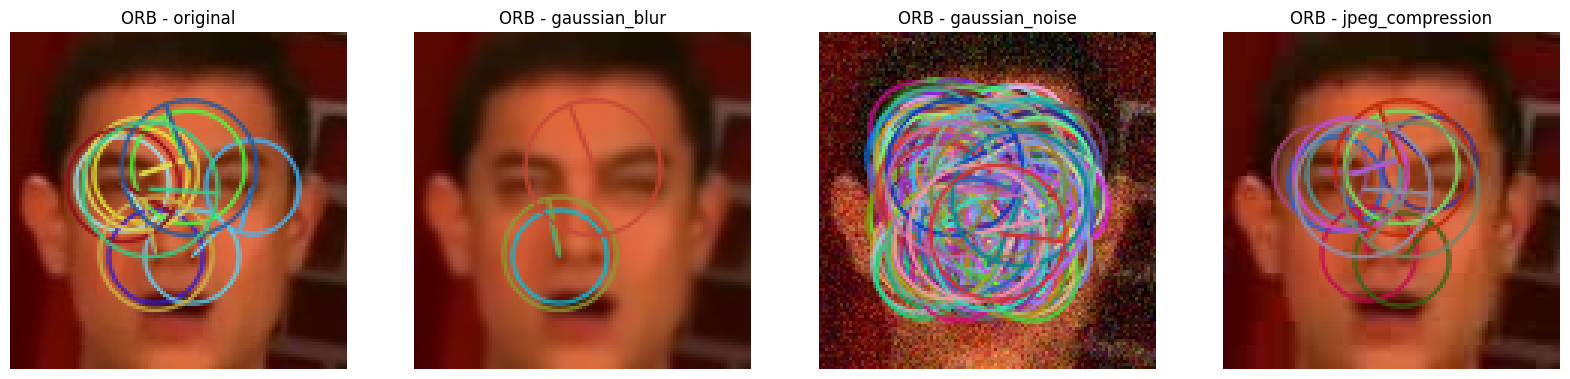

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(20,5))

for ax, (augmentation, data) in zip(axes, images.items()):

    visualization = cv2.drawKeypoints(
        data["rgb"],
        orb_results[augmentation]["keypoints"],
        None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )

    ax.imshow(visualization)
    ax.set_title(f"ORB - {augmentation}")
    ax.axis("off")

plt.show()

# 6. AKAZE Feature Extraction

AKAZE (Accelerated KAZE) merupakan metode feature extraction yang menggunakan nonlinear scale space untuk mendeteksi fitur lokal pada citra. Berbeda dengan ORB, AKAZE dirancang untuk menghasilkan fitur yang lebih stabil pada kondisi citra yang mengalami blur, noise, atau compression.

Keunggulan AKAZE:
- lebih stabil pada citra terdegradasi
- mempertahankan struktur lokal citra
- menghasilkan descriptor biner yang efisien
- memiliki robustness yang baik terhadap perubahan kualitas citra

Pada tahap ini, AKAZE digunakan untuk mendeteksi keypoints dan descriptor dari citra grayscale untuk dibandingkan dengan ORB.

In [18]:
akaze = cv2.AKAZE_create()

akaze_results = {}

for augmentation, data in images.items():

    keypoints, descriptors = akaze.detectAndCompute(
        data["gray"],
        None
    )

    akaze_results[augmentation] = {
        "keypoints": keypoints,
        "descriptors": descriptors,
    }

    print(f"\nAugmentation: {augmentation}")
    print("Number of keypoints:", len(keypoints))
    print("Descriptor shape:", descriptors.shape)
    print("Descriptor mean:", np.mean(descriptors))
    print("Descriptor variance:", np.var(descriptors))


Augmentation: original
Number of keypoints: 5
Descriptor shape: (5, 61)
Descriptor mean: 118.39016393442623
Descriptor variance: 8762.526460628864

Augmentation: gaussian_blur
Number of keypoints: 2
Descriptor shape: (2, 61)
Descriptor mean: 129.88524590163934
Descriptor variance: 7656.888470841172

Augmentation: gaussian_noise
Number of keypoints: 6
Descriptor shape: (6, 61)
Descriptor mean: 128.13114754098362
Descriptor variance: 8278.195915076592

Augmentation: jpeg_compression
Number of keypoints: 5
Descriptor shape: (5, 61)
Descriptor mean: 118.30819672131148
Descriptor variance: 9039.249277076055


# 7. Visualisasi Keypoints AKAZE

Visualisasi keypoints AKAZE digunakan untuk melihat distribusi titik fitur yang berhasil dideteksi pada citra.

Dengan membandingkan visualisasi ORB dan AKAZE, dapat diamati perbedaan karakteristik kedua metode dalam mendeteksi struktur lokal citra pada berbagai kondisi augmentasi.

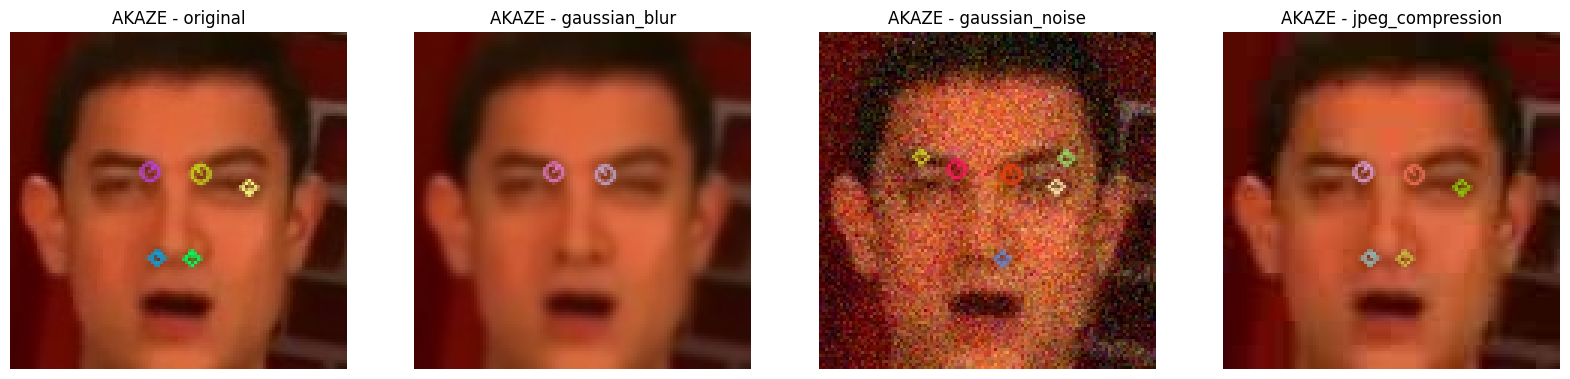

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(20,5))

for ax, (augmentation, data) in zip(axes, images.items()):

    visualization = cv2.drawKeypoints(
        data["rgb"],
        akaze_results[augmentation]["keypoints"],
        None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )

    ax.imshow(visualization)
    ax.set_title(f"AKAZE - {augmentation}")
    ax.axis("off")

plt.show()

# 8. Perbandingan Jumlah Keypoints

Bagian ini menampilkan perbandingan jumlah keypoints yang dihasilkan oleh ORB dan AKAZE.

Jumlah keypoints digunakan sebagai indikator awal untuk melihat seberapa banyak informasi lokal yang berhasil dideteksi oleh masing-masing metode. Namun, jumlah keypoints yang lebih banyak tidak selalu berarti lebih baik, karena stabilitas dan kualitas descriptor juga mempengaruhi performa feature extraction.

In [20]:
comparison_data = []

for augmentation in images.keys():

    comparison_data.append({
        "augmentation": augmentation,
        "ORB": len(orb_results[augmentation]["keypoints"]),
        "AKAZE": len(akaze_results[augmentation]["keypoints"]),
    })

comparison_df = pd.DataFrame(comparison_data)

comparison_df

,augmentation,ORB,AKAZE
0,original,11,5
1,gaussian_blur,3,2
2,gaussian_noise,176,6
3,jpeg_compression,11,5


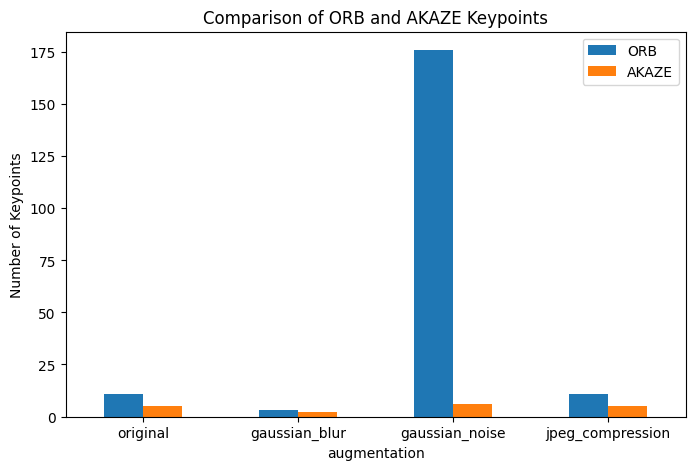

In [21]:
comparison_df.plot(
    x="augmentation",
    y=["ORB", "AKAZE"],
    kind="bar",
    figsize=(8,5)
)

plt.title("Comparison of ORB and AKAZE Keypoints")
plt.ylabel("Number of Keypoints")
plt.xticks(rotation=0)

plt.show()

# 9. Analisis Pengaruh Augmentasi

Pada tahap ini dilakukan analisis terhadap pengaruh augmentasi citra seperti Gaussian blur, Gaussian noise, dan JPEG compression terhadap hasil feature extraction.

Setiap augmentasi dapat mempengaruhi:
- jumlah keypoints yang terdeteksi
- distribusi descriptor
- stabilitas fitur lokal
- kualitas representasi citra

Hasil analisis digunakan untuk membandingkan robustness ORB dan AKAZE pada kondisi citra yang berbeda.

In [22]:
statistics_rows = []

for augmentation in images.keys():

    orb_descriptors = orb_results[augmentation]["descriptors"]
    akaze_descriptors = akaze_results[augmentation]["descriptors"]

    statistics_rows.append({
        "augmentation": augmentation,
        "method": "ORB",
        "num_keypoints": len(orb_results[augmentation]["keypoints"]),
        "descriptor_mean": np.mean(orb_descriptors),
        "descriptor_variance": np.var(orb_descriptors),
    })

    statistics_rows.append({
        "augmentation": augmentation,
        "method": "AKAZE",
        "num_keypoints": len(akaze_results[augmentation]["keypoints"]),
        "descriptor_mean": np.mean(akaze_descriptors),
        "descriptor_variance": np.var(akaze_descriptors),
    })

statistics_df = pd.DataFrame(statistics_rows)

statistics_df

,augmentation,method,num_keypoints,descriptor_mean,descriptor_variance
0,original,ORB,11,137.511364,5101.891916
1,original,AKAZE,5,118.390164,8762.526461
2,gaussian_blur,ORB,3,139.458333,5744.477431
3,gaussian_blur,AKAZE,2,129.885246,7656.888471
4,gaussian_noise,ORB,176,132.621804,5645.495107
5,gaussian_noise,AKAZE,6,128.131148,8278.195915
6,jpeg_compression,ORB,11,139.019886,5594.837673
7,jpeg_compression,AKAZE,5,118.308197,9039.249277


# 10. Kesimpulan

Berdasarkan hasil analisis feature extraction:

- ORB memiliki performa yang cepat dan ringan sehingga cocok digunakan untuk aplikasi real-time.
- AKAZE cenderung lebih stabil pada citra yang mengalami blur dan compression karena menggunakan nonlinear scale space.
- Augmentasi citra seperti noise, blur, dan compression dapat mengurangi jumlah keypoints dan mempengaruhi kualitas descriptor.
- Pemilihan metode feature extraction bergantung pada kebutuhan aplikasi, kondisi citra, dan trade-off antara kecepatan dan stabilitas fitur.